# Day 2–3 — Data Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/raw/Telco-Customer-Churn.csv')
print(f'Loaded: {df.shape}')

Loaded: (7043, 21)


## Step 1 — Fix TotalCharges dtype

In [2]:
# TotalCharges has blank strings (' ') for ~11 customers with tenure=0
# Coerce forces those blanks to NaN so we can handle them explicitly
print('Before fix:', df['TotalCharges'].dtype)
print('Problematic values:', df[df['TotalCharges'].str.strip() == ''][['customerID','tenure','TotalCharges']].shape[0], 'rows')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('After fix:', df['TotalCharges'].dtype)

Before fix: str
Problematic values: 11 rows
After fix: float64


## Step 2 — Handle missing values

In [3]:
# Check missing values across all columns
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Columns with nulls:')
print(missing)

# For the ~11 TotalCharges nulls: these are new customers (tenure=0)
# MonthlyCharges * tenure = 0, so TotalCharges = 0 is the right fill
# Alternatively drop them — both are fine at this dataset size
print('\nRows with null TotalCharges:')
print(df[df['TotalCharges'].isnull()][['tenure','MonthlyCharges','TotalCharges']])

Columns with nulls:
TotalCharges    11
dtype: int64

Rows with null TotalCharges:
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN
6754       0           61.90           NaN


In [4]:
# Fill with 0 (tenure=0 means no charges yet) OR drop — we drop here for safety
df.dropna(subset=['TotalCharges'], inplace=True)
print(f'Shape after dropping null TotalCharges: {df.shape}')
print(f'Remaining nulls: {df.isnull().sum().sum()}')

Shape after dropping null TotalCharges: (7032, 21)
Remaining nulls: 0


## Step 3 — Drop customerID

In [5]:
# customerID is a unique identifier — not predictive
df.drop(columns=['customerID'], inplace=True)
print(f'Columns after drop: {df.shape[1]}')

Columns after drop: 20


## Step 4 — Encode target column

In [6]:
# Churn: Yes → 1, No → 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print('Churn encoded:')
print(df['Churn'].value_counts())

Churn encoded:
Churn
0    5163
1    1869
Name: count, dtype: int64


## Step 5 — Explore class balance

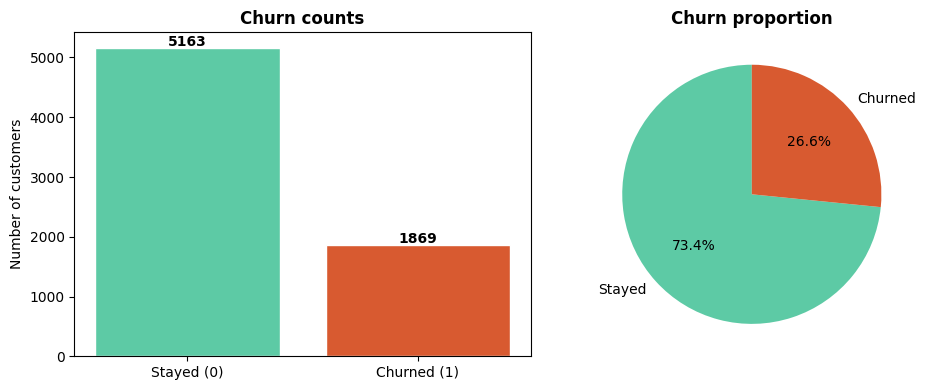

Saved → images/churn_rate.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
counts = df['Churn'].value_counts()
axes[0].bar(['Stayed (0)', 'Churned (1)'], counts.values, color=['#5DCAA5', '#D85A30'], edgecolor='white')
axes[0].set_title('Churn counts', fontweight='bold')
axes[0].set_ylabel('Number of customers')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Proportion pie
props = df['Churn'].value_counts(normalize=True)
axes[1].pie(props.values, labels=['Stayed', 'Churned'], autopct='%1.1f%%',
            colors=['#5DCAA5', '#D85A30'], startangle=90)
axes[1].set_title('Churn proportion', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/churn_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → images/churn_rate.png')

## Step 6 — Final dtype audit

In [8]:
# Confirm all types look correct before saving
print('Numeric columns:')
print(df.select_dtypes(include='number').columns.tolist())
print()
print('Object columns:')
print(df.select_dtypes(include='object').columns.tolist())
print()
print('Final shape:', df.shape)

Numeric columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']

Object columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Final shape: (7032, 20)


## Step 7 — Save cleaned dataset

In [9]:
df.to_csv('../data/processed/cleaned_churn.csv', index=False)
print('Saved → data/processed/cleaned_churn.csv')
print(f'Final shape: {df.shape}')

Saved → data/processed/cleaned_churn.csv
Final shape: (7032, 20)
